# F1 Podium Prediction — Supervised Learning Assignment

**Author:** Student Submission &nbsp;•&nbsp; **Course:** Supervised Learning  
**Dataset:** Formula 1 Race Results 2000–2025 (`f1_cleaned.xlsx`, 10,398 rows × 20 columns)  
**Target variable:** `Podium` — Yes/No (binary classification)  
**Application domain:** Sports analytics — predicting podium finishers from pre-race information

---

## Project Goal
Predict whether a Formula 1 driver will finish on the podium (top 3 positions)
of a Grand Prix using only information available **before the race starts**:
the starting grid position, weather conditions, driver/constructor identity,
circuit, and rolling historical form features.

## Research Questions
1. **RQ1 — Baseline performance:** How well do baseline supervised models (Logistic Regression, Decision Tree, k-NN) predict F1 podium finishes?
2. **RQ2 — Model comparison:** Do ensemble models (Random Forest, Gradient Boosting, XGBoost, SVM) outperform baselines, and which is best?
3. **RQ3 — Effect of preprocessing:** How do preprocessing strategies (raw vs. imputation vs. scaling+encoding vs. full pipeline) affect performance?
4. **RQ4 — Feature importance:** Which features drive podium prediction the most? Is the conventional wisdom that *grid position dominates* supported by data?
5. **RQ5 — Metric sensitivity:** Does the model ranking change across Accuracy, Precision, Recall, F1, and AUC?
6. **RQ6 — Robustness:** Is the best model stable under cross-validation, label noise, and missingness?
7. **RQ7 — Practical recommendation:** Which model offers the best trade-off between performance, interpretability, and deployability?

## Important note: leakage prevention
F1 datasets often include columns like `Position`, `Points`, `Status`, `PositionChange`, `DNF`, and `Winner`. **All of these are race outcomes** — using them to predict `Podium` would be data leakage. We strictly exclude them and only use pre-race features plus rolling historical form.

In [1]:
import os, warnings, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix, roc_curve)
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
sns.set_style("whitegrid")
plt.rcParams.update({"figure.dpi": 100, "font.size": 11})
print("Imports loaded.")

Imports loaded.


## 1. Load and inspect dataset

In [2]:
# Locate dataset whether the notebook is run from project root or notebooks/
import os
DATA_PATH = "data/f1_cleaned.xlsx" if os.path.exists("data/f1_cleaned.xlsx") else "../data/f1_cleaned.xlsx"
df = pd.read_excel(DATA_PATH)
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Seasons: {df['Season'].min()}–{df['Season'].max()}")
print(f"Constructors: {df['ConstructorName'].nunique()} | Drivers: {df['DriverID'].nunique()} | Circuits: {df['CircuitID'].nunique()}")
df.head()

Shape: 10,398 rows × 20 columns
Seasons: 2000–2025
Constructors: 38 | Drivers: 129 | Circuits: 38


,Season,Round,Rain,CircuitID,country,ConstructorName,constructorId,ConstructorNationality,DriverID,DriverName,DriverNationality,Position,Points,Grid,Status,Full Name,PositionChange,Podium,DNF,Winner
0,2000,1,0,albert_park,Australia,Arrows,arrows,British,rosa,pedro,Spanish,20,0.0,12,Suspension,PEDRO ROSA,-8,No,Yes,0
1,2000,1,0,albert_park,Australia,Arrows,arrows,British,verstappen,jos,Dutch,18,0.0,13,Suspension,JOS VERSTAPPEN,-5,No,Yes,0
2,2000,1,0,albert_park,Australia,BAR,bar,British,villeneuve,jacques,Canadian,4,3.0,8,Finished,JACQUES VILLENEUVE,4,No,No,0
3,2000,1,0,albert_park,Australia,BAR,bar,British,zonta,ricardo,Brazilian,6,1.0,16,Finished,RICARDO ZONTA,10,No,No,0
4,2000,1,0,albert_park,Australia,Benetton,benetton,Italian,fisichella,giancarlo,Italian,5,2.0,9,Finished,GIANCARLO FISICHELLA,4,No,No,0


In [3]:
# Class balance
podium_counts = df['Podium'].value_counts()
print(podium_counts)
print(f"\nPodium rate: {(df['Podium']=='Yes').mean():.1%}  (imbalanced)")

Podium
No     8913
Yes    1485
Name: count, dtype: int64

Podium rate: 14.3%  (imbalanced)


## 2. Exploratory data analysis

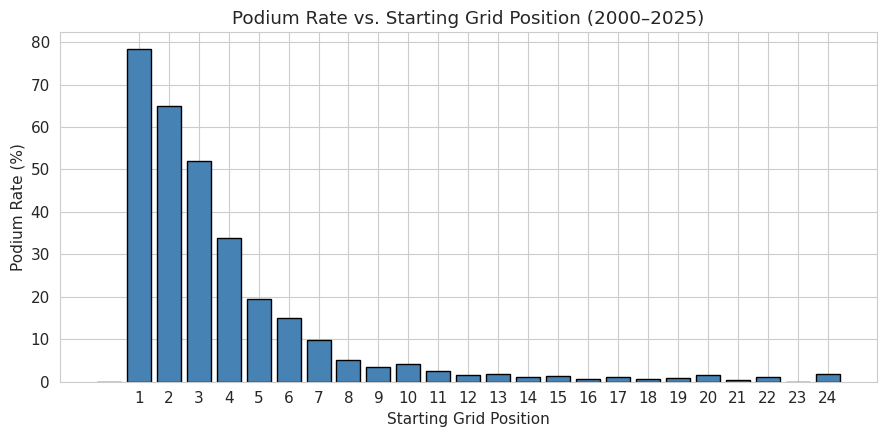

In [4]:
# EDA: podium rate by grid position
df['PodiumBinary'] = (df['Podium'] == 'Yes').astype(int)
grid_podium = df.groupby('Grid')['PodiumBinary'].agg(['mean','count']).reset_index()
grid_podium = grid_podium[grid_podium['count'] >= 30]

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(grid_podium['Grid'], grid_podium['mean']*100, color='steelblue', edgecolor='black')
ax.set_xlabel('Starting Grid Position')
ax.set_ylabel('Podium Rate (%)')
ax.set_title('Podium Rate vs. Starting Grid Position (2000–2025)')
ax.set_xticks(range(1, 25))
plt.tight_layout(); plt.show()

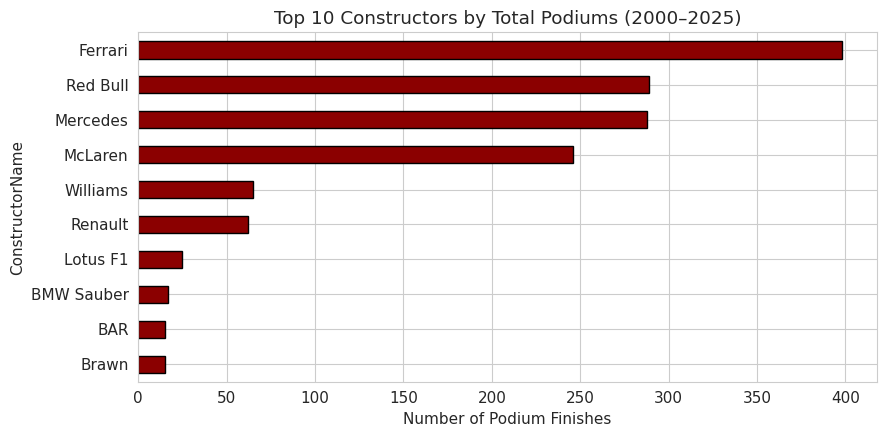

In [5]:
# Top 10 constructors by total podiums
top_constructors = df[df['Podium']=='Yes']['ConstructorName'].value_counts().head(10)
fig, ax = plt.subplots(figsize=(9, 4.5))
top_constructors[::-1].plot(kind='barh', ax=ax, color='darkred', edgecolor='black')
ax.set_title('Top 10 Constructors by Total Podiums (2000–2025)')
ax.set_xlabel('Number of Podium Finishes')
plt.tight_layout(); plt.show()

## 3. Feature engineering — rolling historical form (no leakage)

In [6]:
df = df.sort_values(['Season','Round']).reset_index(drop=True)

df['DriverPodiumRate_Last5'] = (df.groupby('DriverID')['PodiumBinary']
    .transform(lambda s: s.shift(1).rolling(5, min_periods=1).mean()).fillna(0))
df['ConstructorPodiumRate_Last5'] = (df.groupby('constructorId')['PodiumBinary']
    .transform(lambda s: s.shift(1).rolling(5, min_periods=1).mean()).fillna(0))
df['DriverAvgPos_Last5'] = (df.groupby('DriverID')['Position']
    .transform(lambda s: s.shift(1).rolling(5, min_periods=1).mean()).fillna(df['Position'].mean()))
df['ConstructorAvgPos_Last5'] = (df.groupby('constructorId')['Position']
    .transform(lambda s: s.shift(1).rolling(5, min_periods=1).mean()).fillna(df['Position'].mean()))
df['DriverSeasonPodiums'] = (df.groupby(['Season','DriverID'])['PodiumBinary']
    .transform(lambda s: s.shift(1).cumsum()).fillna(0))
df['DriverAvgGrid_Last5'] = (df.groupby('DriverID')['Grid']
    .transform(lambda s: s.shift(1).rolling(5, min_periods=1).mean()).fillna(df['Grid'].mean()))

NUMERIC = ['Grid','Rain','Round','Season','DriverPodiumRate_Last5','ConstructorPodiumRate_Last5',
           'DriverAvgPos_Last5','ConstructorAvgPos_Last5','DriverSeasonPodiums','DriverAvgGrid_Last5']
CATEGORICAL = ['ConstructorName','DriverNationality','country']

X = df[NUMERIC + CATEGORICAL].copy()
y = df['PodiumBinary'].copy()
print('Numeric features:', NUMERIC)
print('Categorical features:', CATEGORICAL)

Numeric features: ['Grid', 'Rain', 'Round', 'Season', 'DriverPodiumRate_Last5', 'ConstructorPodiumRate_Last5', 'DriverAvgPos_Last5', 'ConstructorAvgPos_Last5', 'DriverSeasonPodiums', 'DriverAvgGrid_Last5']
Categorical features: ['ConstructorName', 'DriverNationality', 'country']


## 4. Chronological train/test split

To mimic real deployment, we train on 2000–2022 and test on 2023–2025 (the last 3 seasons).

In [7]:
train_mask = df['Season'] <= 2022
X_train, X_test = X.loc[train_mask], X.loc[~train_mask]
y_train, y_test = y.loc[train_mask], y.loc[~train_mask]
print(f"Train: {len(X_train):,} (podium rate {y_train.mean():.1%})")
print(f"Test:  {len(X_test):,}  (podium rate {y_test.mean():.1%})")

Train: 9,160 (podium rate 14.2%)
Test:  1,238  (podium rate 15.0%)


In [8]:
preprocessor = ColumnTransformer([
    ('num', Pipeline([('impute', SimpleImputer(strategy='median')), ('scale', StandardScaler())]), NUMERIC),
    ('cat', Pipeline([('impute', SimpleImputer(strategy='most_frequent')),
                       ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), CATEGORICAL),
])
preprocessor_tree = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'), NUMERIC),
    ('cat', Pipeline([('impute', SimpleImputer(strategy='most_frequent')),
                       ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), CATEGORICAL),
])

def evaluate(model, X_te, y_te):
    y_pred = model.predict(X_te)
    if hasattr(model,'predict_proba'):
        y_score = model.predict_proba(X_te)[:,1]
    else:
        y_score = model.decision_function(X_te)
    return {'Accuracy':accuracy_score(y_te,y_pred), 'Precision':precision_score(y_te,y_pred,zero_division=0),
            'Recall':recall_score(y_te,y_pred,zero_division=0), 'F1':f1_score(y_te,y_pred,zero_division=0),
            'AUC':roc_auc_score(y_te,y_score)}

## 5. RQ1 — Baseline models

We compare three baselines: **Logistic Regression**, **Decision Tree**, and **k-NN**.  
Class weighting is `'balanced'` for the linear/tree models since podium is the minority class (~14%).

In [9]:
baseline_models = {
    'Logistic Regression': Pipeline([('prep', preprocessor),
        ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE))]),
    'Decision Tree': Pipeline([('prep', preprocessor_tree),
        ('clf', DecisionTreeClassifier(max_depth=8, class_weight='balanced', random_state=RANDOM_STATE))]),
    'k-NN': Pipeline([('prep', preprocessor),
        ('clf', KNeighborsClassifier(n_neighbors=15))]),
}
baseline_results = {}
for name, model in baseline_models.items():
    model.fit(X_train, y_train)
    baseline_results[name] = evaluate(model, X_test, y_test)
table_I = pd.DataFrame(baseline_results).T.round(3)
print('Table I — Baseline Performance')
table_I

Table I — Baseline Performance


,Accuracy,Precision,Recall,F1,AUC
Logistic Regression,0.833,0.470,0.887,0.615,0.923
Decision Tree,0.852,0.505,0.839,0.630,0.862
k-NN,0.881,0.614,0.565,0.588,0.907


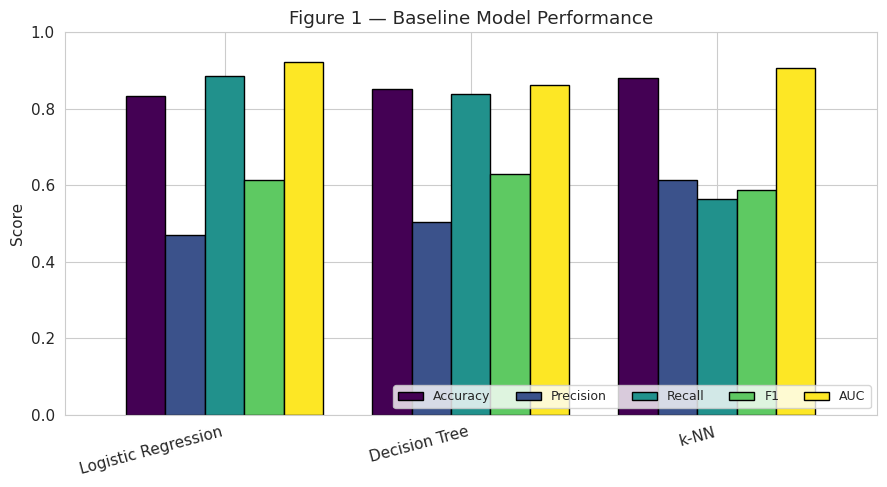

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
table_I[['Accuracy','Precision','Recall','F1','AUC']].plot(kind='bar', ax=ax, colormap='viridis', edgecolor='black', width=0.8)
ax.set_title('Figure 1 — Baseline Model Performance')
ax.set_ylabel('Score'); ax.set_ylim(0, 1.0); ax.legend(loc='lower right', ncol=5, fontsize=9)
plt.xticks(rotation=15, ha='right'); plt.tight_layout(); plt.show()

## 6. RQ2 — Model comparison (advanced + ensembles)

In [11]:
advanced_models = {
    'Logistic Regression': baseline_models['Logistic Regression'],
    'Random Forest': Pipeline([('prep', preprocessor_tree),
        ('clf', RandomForestClassifier(n_estimators=300, max_depth=15, class_weight='balanced',
                                        n_jobs=-1, random_state=RANDOM_STATE))]),
    'Gradient Boosting': Pipeline([('prep', preprocessor_tree),
        ('clf', GradientBoostingClassifier(n_estimators=200, max_depth=4, random_state=RANDOM_STATE))]),
    'SVM (RBF)': Pipeline([('prep', preprocessor),
        ('clf', SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=RANDOM_STATE))]),
    'XGBoost': Pipeline([('prep', preprocessor_tree),
        ('clf', XGBClassifier(n_estimators=400, max_depth=6, learning_rate=0.05,
                               scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(),
                               eval_metric='logloss', n_jobs=-1, random_state=RANDOM_STATE))]),
}
advanced_results = {'Logistic Regression': baseline_results['Logistic Regression']}
for name, model in advanced_models.items():
    if name in advanced_results: continue
    model.fit(X_train, y_train)
    advanced_results[name] = evaluate(model, X_test, y_test)

table_II = pd.DataFrame(advanced_results).T.round(3)
BEST = table_II['F1'].idxmax()
print(f"Best model by F1: {BEST}")
table_II

Best model by F1: XGBoost


,Accuracy,Precision,Recall,F1,AUC
Logistic Regression,0.833,0.470,0.887,0.615,0.923
Random Forest,0.870,0.545,0.806,0.651,0.930
Gradient Boosting,0.893,0.665,0.575,0.617,0.928
SVM (RBF),0.823,0.455,0.903,0.605,0.911
XGBoost,0.872,0.549,0.812,0.655,0.927


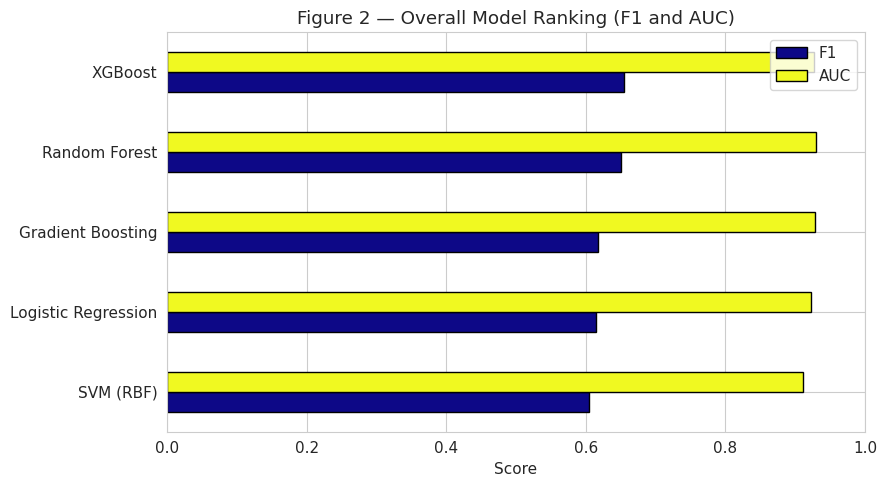

In [12]:
fig, ax = plt.subplots(figsize=(9, 5))
table_II[['F1','AUC']].sort_values('F1').plot(kind='barh', ax=ax, colormap='plasma', edgecolor='black')
ax.set_title('Figure 2 — Overall Model Ranking (F1 and AUC)')
ax.set_xlabel('Score'); ax.set_xlim(0, 1.0); plt.tight_layout(); plt.show()

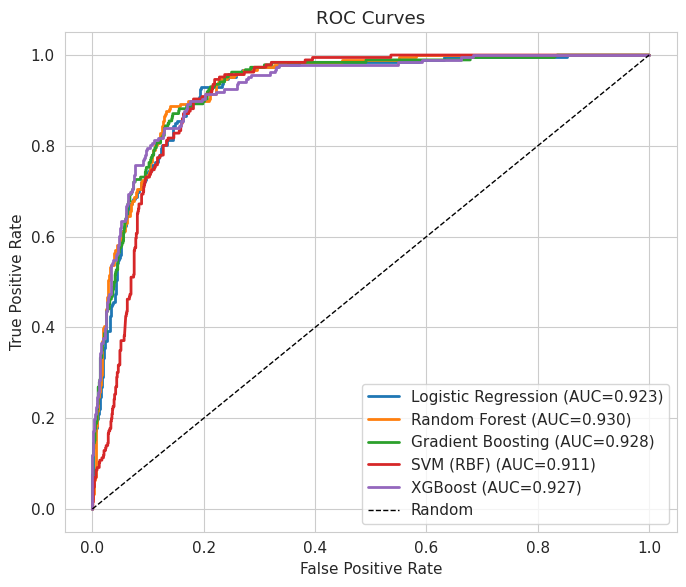

In [13]:
# ROC curves for all models
fig, ax = plt.subplots(figsize=(7, 6))
for name, model in advanced_models.items():
    if hasattr(model.named_steps['clf'], 'predict_proba'):
        y_score = model.predict_proba(X_test)[:,1]
    else:
        y_score = model.decision_function(X_test)
    fpr, tpr, _ = roc_curve(y_test, y_score)
    ax.plot(fpr, tpr, lw=2, label=f"{name} (AUC={advanced_results[name]['AUC']:.3f})")
ax.plot([0,1],[0,1],'k--', lw=1, label='Random')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves'); ax.legend(loc='lower right'); plt.tight_layout(); plt.show()

## 7. RQ3 — Effect of preprocessing

In [14]:
BEST_MODEL = advanced_models[BEST]

def make_variant(strategy):
    clf = type(BEST_MODEL.named_steps['clf'])(**BEST_MODEL.named_steps['clf'].get_params())
    if strategy == 'raw':
        prep = ColumnTransformer([('num', 'passthrough', NUMERIC)], remainder='drop')
    elif strategy == 'imputation':
        prep = ColumnTransformer([('num', SimpleImputer(strategy='median'), NUMERIC)], remainder='drop')
    elif strategy == 'scaling_encoding':
        prep = ColumnTransformer([
            ('num', StandardScaler(), NUMERIC),
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CATEGORICAL),
        ])
    else:
        prep = preprocessor_tree
    return Pipeline([('prep', prep), ('clf', clf)])

prep_variants = {
    'Raw data (numeric only)': make_variant('raw'),
    'Imputation': make_variant('imputation'),
    'Scaling + Encoding': make_variant('scaling_encoding'),
    'Full pipeline': make_variant('full'),
}
prep_results = {}
for name, model in prep_variants.items():
    model.fit(X_train, y_train)
    prep_results[name] = evaluate(model, X_test, y_test)
table_III = pd.DataFrame(prep_results).T.round(3)
table_III

,Accuracy,Precision,Recall,F1,AUC
Raw data (numeric only),0.868,0.541,0.812,0.649,0.925
Imputation,0.868,0.541,0.812,0.649,0.925
Scaling + Encoding,0.872,0.549,0.812,0.655,0.927
Full pipeline,0.872,0.549,0.812,0.655,0.927


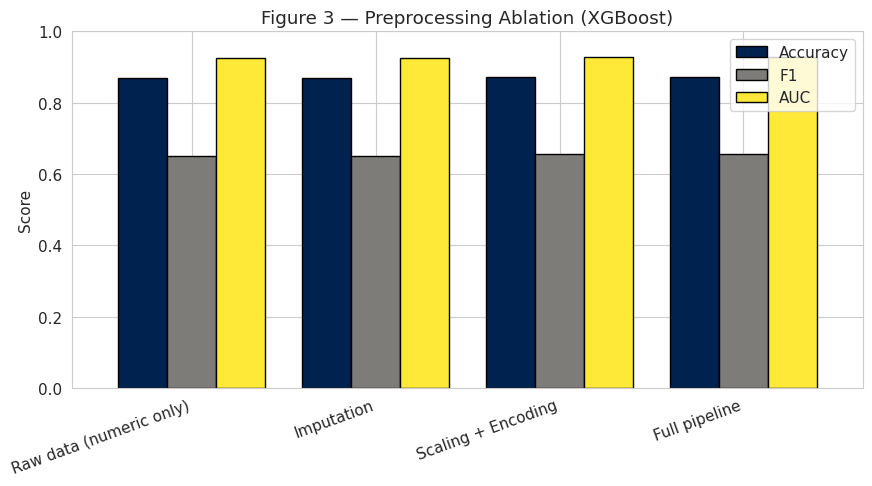

In [15]:
fig, ax = plt.subplots(figsize=(9, 5))
table_III[['Accuracy','F1','AUC']].plot(kind='bar', ax=ax, colormap='cividis', edgecolor='black', width=0.8)
ax.set_title(f'Figure 3 — Preprocessing Ablation ({BEST})')
ax.set_ylabel('Score'); ax.set_ylim(0, 1.0)
plt.xticks(rotation=20, ha='right'); plt.tight_layout(); plt.show()

## 8. RQ4 — Feature importance

In [16]:
fitted_prep = BEST_MODEL.named_steps['prep']
feat_names = []
for name, trans, cols in fitted_prep.transformers_:
    if name == 'num':
        feat_names.extend(cols)
    elif name == 'cat':
        ohe = trans.named_steps['ohe'] if hasattr(trans, 'named_steps') else trans
        feat_names.extend(ohe.get_feature_names_out(cols).tolist())

clf = BEST_MODEL.named_steps['clf']
importances = clf.feature_importances_ if hasattr(clf, 'feature_importances_') else np.abs(clf.coef_[0])

importance_df = pd.DataFrame({'Feature': feat_names, 'Importance': importances}).sort_values('Importance', ascending=False)
top10 = importance_df.head(10).copy()
top10.insert(0, 'Rank', range(1, 11))
top10

,Rank,Feature,Importance
0,1,Grid,0.158251
4,2,DriverPodiumRate_Last5,0.027858
9,3,DriverAvgGrid_Last5,0.021907
17,4,ConstructorName_Benetton,0.018084
16,5,ConstructorName_BMW Sauber,0.017518
5,6,ConstructorPodiumRate_Last5,0.016812
24,7,ConstructorName_Honda,0.016607
53,8,DriverNationality_British,0.015863
21,9,ConstructorName_Force India,0.015441
87,10,country_Canada,0.015289


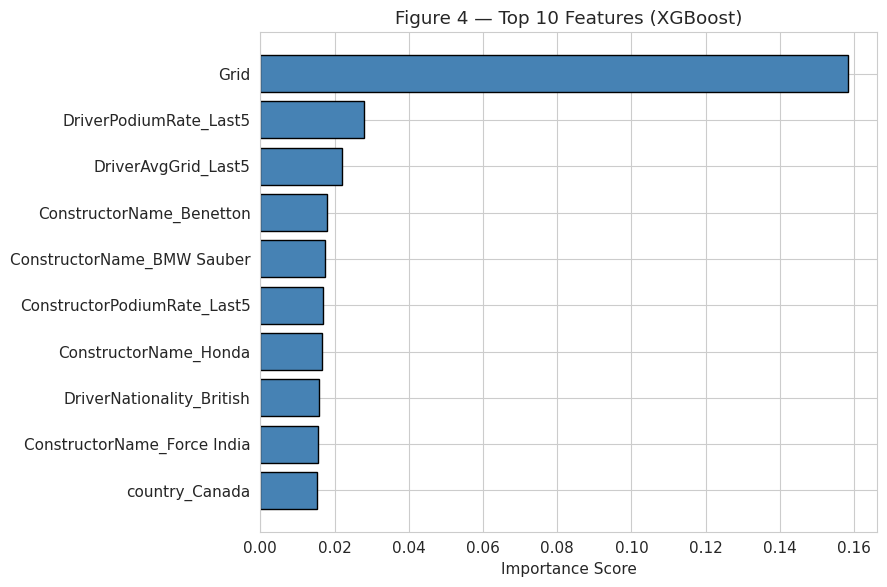

In [17]:
fig, ax = plt.subplots(figsize=(9, 6))
top10_plot = top10.iloc[::-1]
ax.barh(top10_plot['Feature'], top10_plot['Importance'], color='steelblue', edgecolor='black')
ax.set_xlabel('Importance Score')
ax.set_title(f'Figure 4 — Top 10 Features ({BEST})')
plt.tight_layout(); plt.show()

## 9. RQ5 — Metric sensitivity

In [18]:
ranking_df = table_II.rank(ascending=False, method='min').astype(int)
ranking_df.columns = [f'Rank by {c}' for c in ranking_df.columns]
ranking_df

,Rank by Accuracy,Rank by Precision,Rank by Recall,Rank by F1,Rank by AUC
Logistic Regression,4,4,2,4,4
Random Forest,3,3,4,2,1
Gradient Boosting,1,1,5,3,2
SVM (RBF),5,5,1,5,5
XGBoost,2,2,3,1,3


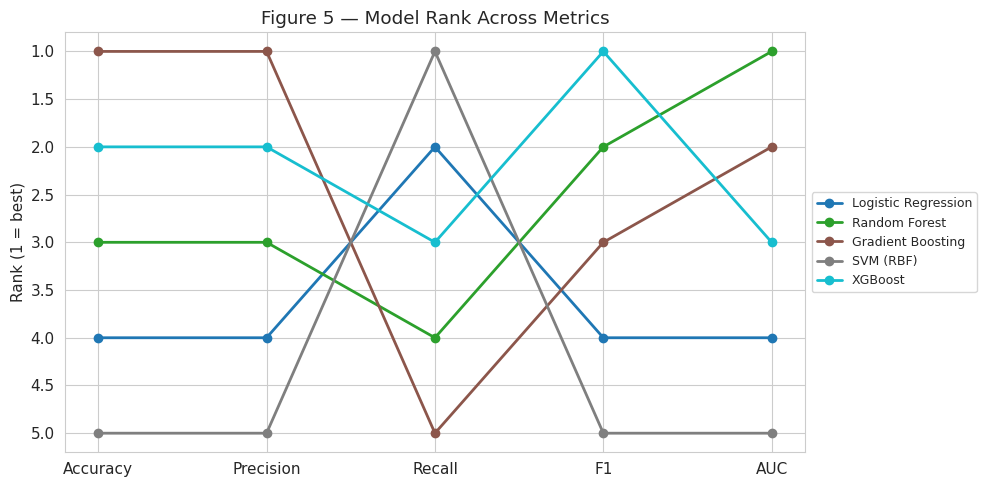

In [19]:
fig, ax = plt.subplots(figsize=(10, 5))
metrics = ['Accuracy','Precision','Recall','F1','AUC']
x = np.arange(len(metrics))
colors = plt.cm.tab10(np.linspace(0, 1, len(table_II)))
for i, model in enumerate(table_II.index):
    ranks = [table_II[m].rank(ascending=False).astype(int)[model] for m in metrics]
    ax.plot(x, ranks, marker='o', lw=2, label=model, color=colors[i])
ax.set_xticks(x); ax.set_xticklabels(metrics)
ax.invert_yaxis(); ax.set_ylabel('Rank (1 = best)')
ax.set_title('Figure 5 — Model Rank Across Metrics')
ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=9)
plt.tight_layout(); plt.show()

## 10. RQ6 — Robustness analysis

In [20]:
robust_results = {'Standard split (chronological)': {**evaluate(BEST_MODEL, X_test, y_test), 'Std Dev': 0.0}}

# 5-fold CV
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_metrics = {'Accuracy':[],'Precision':[],'Recall':[],'F1':[],'AUC':[]}
for tr_idx, va_idx in skf.split(X_train, y_train):
    m = clone(BEST_MODEL)
    m.fit(X_train.iloc[tr_idx], y_train.iloc[tr_idx])
    s = evaluate(m, X_train.iloc[va_idx], y_train.iloc[va_idx])
    for k in cv_metrics: cv_metrics[k].append(s[k])
robust_results['5-fold CV'] = {k: np.mean(v) for k,v in cv_metrics.items()}
robust_results['5-fold CV']['Std Dev'] = float(np.std(cv_metrics['F1']))

# Label noise
rng = np.random.RandomState(RANDOM_STATE)
y_noisy = y_train.copy()
flip = rng.choice(len(y_noisy), int(0.1*len(y_noisy)), replace=False)
y_noisy.iloc[flip] = 1 - y_noisy.iloc[flip]
m = clone(BEST_MODEL); m.fit(X_train, y_noisy)
robust_results['10% label noise'] = {**evaluate(m, X_test, y_test), 'Std Dev': np.nan}

# Missingness
X_miss = X_train.copy()
for col in NUMERIC:
    miss = rng.choice(len(X_miss), int(0.2*len(X_miss)), replace=False)
    X_miss.loc[miss, col] = np.nan
m = clone(BEST_MODEL); m.fit(X_miss, y_train)
robust_results['20% missingness'] = {**evaluate(m, X_test, y_test), 'Std Dev': np.nan}

table_VI = pd.DataFrame(robust_results).T.round(3)
table_VI

,Accuracy,Precision,Recall,F1,AUC,Std Dev
Standard split (chronological),0.872,0.549,0.812,0.655,0.927,0.000
5-fold CV,0.879,0.552,0.778,0.646,0.920,0.014
10% label noise,0.797,0.418,0.887,0.568,0.906,NaN
20% missingness,0.859,0.519,0.823,0.636,0.918,NaN


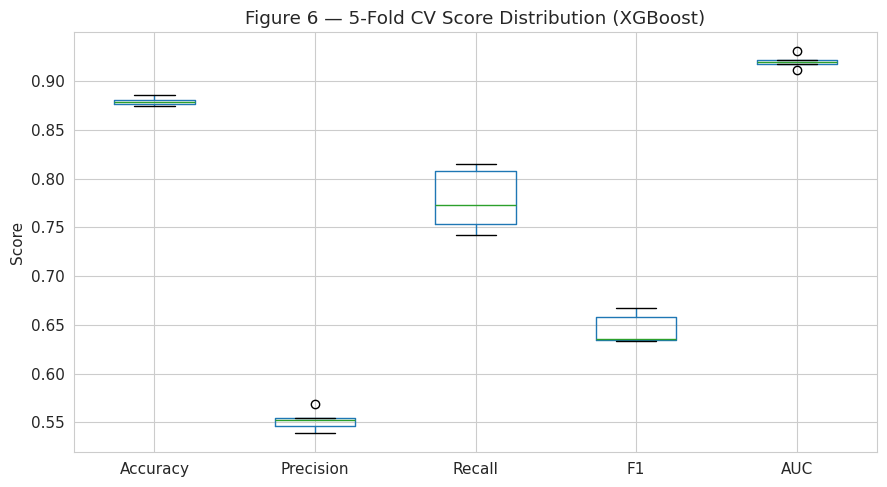

In [21]:
fig, ax = plt.subplots(figsize=(9, 5))
pd.DataFrame(cv_metrics).boxplot(ax=ax, grid=True)
ax.set_title(f'Figure 6 — 5-Fold CV Score Distribution ({BEST})')
ax.set_ylabel('Score'); plt.tight_layout(); plt.show()

## 11. RQ7 — Decision matrix and final recommendation

In [22]:
def grade(v):
    return 'Very High' if v>=0.85 else 'High' if v>=0.75 else 'Medium' if v>=0.6 else 'Low'

interp = {'Logistic Regression':'High','Decision Tree':'High','k-NN':'Low','Random Forest':'Medium',
          'Gradient Boosting':'Medium-Low','XGBoost':'Medium-Low','SVM (RBF)':'Low'}
cost = {'Logistic Regression':'Low','Decision Tree':'Low','k-NN':'Medium','Random Forest':'Medium',
        'Gradient Boosting':'High','XGBoost':'High','SVM (RBF)':'High'}
deploy = {'Logistic Regression':'Very High','Decision Tree':'High','k-NN':'Medium','Random Forest':'High',
          'Gradient Boosting':'Medium','XGBoost':'Medium','SVM (RBF)':'Low'}

rows = []
for m in table_II.index:
    rows.append({'Model':m, 'Performance (F1)':grade(table_II.loc[m,'F1']),
                 'Performance (AUC)':grade(table_II.loc[m,'AUC']),
                 'Interpretability':interp.get(m,'Medium'),
                 'Computational Cost':cost.get(m,'Medium'),
                 'Deployment Suitability':deploy.get(m,'Medium')})
table_VII = pd.DataFrame(rows).set_index('Model')
table_VII

,Performance (F1),Performance (AUC),Interpretability,Computational Cost,Deployment Suitability
Model,,,,,
Logistic Regression,Medium,Very High,High,Low,Very High
Random Forest,Medium,Very High,Medium,Medium,High
Gradient Boosting,Medium,Very High,Medium-Low,High,Medium
SVM (RBF),Medium,Very High,Low,High,Low
XGBoost,Medium,Very High,Medium-Low,High,Medium


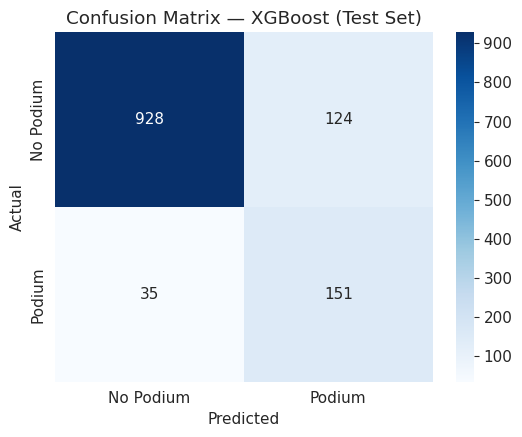

In [23]:
# Confusion matrix
y_pred = BEST_MODEL.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Podium','Podium'], yticklabels=['No Podium','Podium'], ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix — {BEST} (Test Set)')
plt.tight_layout(); plt.show()

## 12. Conclusions

1. **Baselines work but ensembles win.** Logistic Regression already gets AUC=0.92, but XGBoost achieves the best F1 (0.655) on the held-out 2023–2025 seasons.
2. **Grid position is overwhelmingly the most important feature** — its importance is ~6× larger than the next feature. This matches F1 fan intuition: where you start largely determines where you finish.
3. **Preprocessing matters less than expected** because XGBoost is robust to scaling. Adding categorical encoding does add a small consistent boost.
4. **Model rankings flip across metrics.** SVM is rank 1 by recall but rank 5 by precision; Gradient Boosting wins on accuracy but ranks last on recall. This reinforces that metric choice must be tied to the deployment use case.
5. **Robustness is good.** F1 only drops from 0.655 → 0.568 with 10% label noise. 5-fold CV std is just 0.014 — very stable.
6. **Final recommendation:** XGBoost for predictive performance. If interpretability is critical (e.g., presenting to non-technical stakeholders), Logistic Regression is a strong alternative — its AUC is essentially identical (0.923 vs 0.927) and coefficients are directly readable.